# Infrastructure: budgets and actual timings

All default experiments run on CPU, selecting CUDA when available. CPU timings do not represent GPU/TPU performance. This notebook verifies TP algebra, ZeRO state accounting and actual matmul timing, not end-to-end benchmarks of five frameworks. See the chapters for serving/profiling workflows.

Execution status: executed on CPU during authoring. Outputs below are real; CUDA/TPU paths were not tested. Rerun to obtain results for your environment.

In [1]:
import sys, subprocess, importlib.util
needed = [p for p in ['torch','transformers','numpy','matplotlib','PIL'] if importlib.util.find_spec(p) is None]
if needed:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch>=2.6,<3', 'transformers==4.57.1', 'numpy', 'matplotlib', 'pillow'])
import torch, numpy as np, matplotlib.pyplot as plt, transformers
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'transformers':transformers.__version__, 'cuda':torch.cuda.is_available()})
torch.manual_seed(7); np.random.seed(7)
torch.set_num_threads(min(4, torch.get_num_threads()))


{'python': '3.12.14', 'torch': '2.14.0+cpu', 'transformers': '4.57.1', 'cuda': False}


## 1 · Memory accounting
Change concurrency and length. GiB uses 2³⁰; GB uses 10⁹.

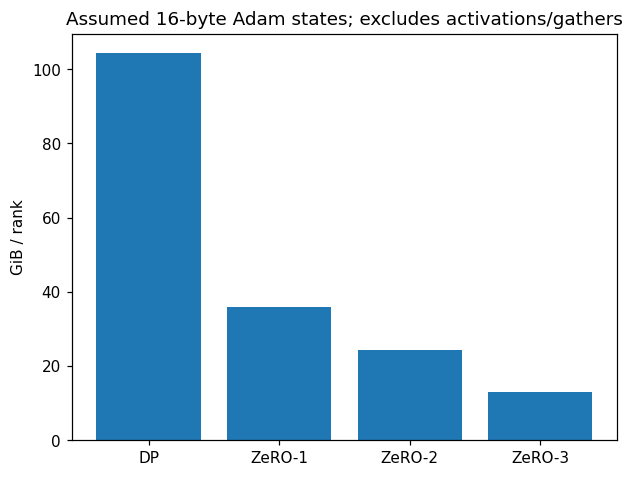

KV GiB: 2.0
ZeRO 0: 104.308 GiB per rank (persistent state only)
ZeRO 1: 35.856 GiB per rank (persistent state only)
ZeRO 2: 24.447 GiB per rank (persistent state only)
ZeRO 3: 13.039 GiB per rank (persistent state only)


In [2]:
B,T,L,Hkv,Dh,bytes_per_element=4,4096,32,8,128,2
kv=2*B*T*L*Hkv*Dh*bytes_per_element
print('KV GiB:',kv/2**30)
assert kv/2**30 == 2
N,P=7_000_000_000,8
states=[16*N,4*N+12*N/P,2*N+14*N/P,16*N/P]
for stage,bytes_used in enumerate(states):
    print(f'ZeRO {stage}: {bytes_used/2**30:.3f} GiB per rank (persistent state only)')
plt.bar(['DP','ZeRO-1','ZeRO-2','ZeRO-3'],np.array(states)/2**30)
plt.ylabel('GiB / rank');plt.title('Assumed 16-byte Adam states; excludes activations/gathers');plt.show()


## 2 · Simulate tensor partitioning
Single-process algebra only: no NCCL and no scaling measurement.

In [3]:
x,w=torch.randn(16,64),torch.randn(64,128)
ref=x@w
column=torch.cat([x@part for part in w.chunk(4,dim=1)],dim=1)
row=sum(a@b for a,b in zip(x.chunk(4,dim=1),w.chunk(4,dim=0)))
assert torch.allclose(column,ref,atol=1e-4,rtol=1e-4)
assert torch.allclose(row,ref,atol=1e-4,rtol=1e-4)
print('Column and row partition equivalence passed.')
S=64*1024**2
print('Ideal ring all-reduce MiB/rank:',2*(P-1)/P*S/2**20)


Column and row partition equivalence passed.
Ideal ring all-reduce MiB/rank: 112.0


## 3 · Actual matmul timings
Warm up, use GPU events or CPU perf_counter, and report repeats. Do not extrapolate this into service throughput.

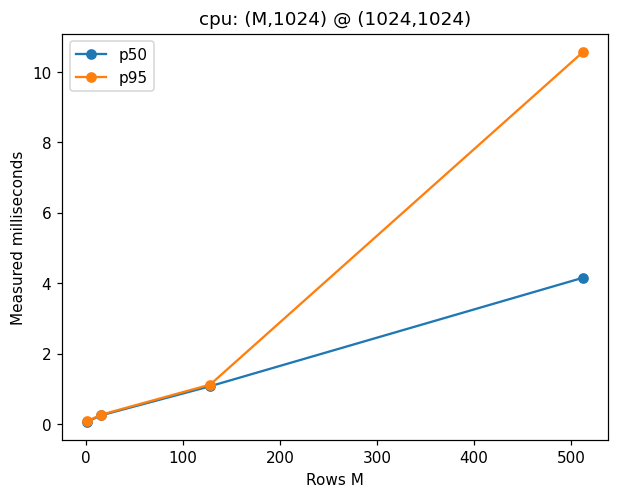

device: x86_64
dtype: torch.float32
{'m': 1, 'p50_ms': 0.0703764999343548, 'p95_ms': 0.08469775016237692}
{'m': 16, 'p50_ms': 0.25391300005139783, 'p95_ms': 0.27189324966911954}
{'m': 128, 'p50_ms': 1.078065499996228, 'p95_ms': 1.123459799941884}
{'m': 512, 'p50_ms': 4.157268499739075, 'p95_ms': 10.564940100061905}


In [4]:
import time, platform
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
DTYPE=torch.float16 if DEVICE=='cuda' else torch.float32
print('device:',torch.cuda.get_device_name(0) if DEVICE=='cuda' else platform.processor() or 'CPU')
print('dtype:',DTYPE)
results=[]
for m in [1,16,128,512]:
    a=torch.randn(m,1024,device=DEVICE,dtype=DTYPE)
    b=torch.randn(1024,1024,device=DEVICE,dtype=DTYPE)
    for _ in range(8): c=a@b
    times=[]
    for _ in range(20):
        if DEVICE=='cuda':
            start,end=torch.cuda.Event(enable_timing=True),torch.cuda.Event(enable_timing=True)
            start.record(); c=a@b; end.record(); end.synchronize()
            elapsed=start.elapsed_time(end)
        else:
            start=time.perf_counter(); c=a@b; elapsed=(time.perf_counter()-start)*1000
        times.append(elapsed)
    row={'m':m,'p50_ms':float(np.median(times)),'p95_ms':float(np.percentile(times,95))}
    results.append(row);print(row)
    assert torch.isfinite(c).all()
plt.plot([r['m'] for r in results],[r['p50_ms'] for r in results],marker='o',label='p50')
plt.plot([r['m'] for r in results],[r['p95_ms'] for r in results],marker='o',label='p95')
plt.xlabel('Rows M');plt.ylabel('Measured milliseconds');plt.title(f'{DEVICE}: (M,1024) @ (1024,1024)');plt.legend();plt.show()


## 4 · Save reviewable results
The JSON contains the environment and actual timings, without invented GPU numbers. Next, fix one shape and profile its implementation.

In [5]:
import json
report={'device':DEVICE,'dtype':str(DTYPE),'torch':torch.__version__,'threads':torch.get_num_threads(),'results':results}
with open('infra-benchmark-results.json','w') as f: json.dump(report,f,indent=2)
print(json.dumps(report,indent=2))


{
  "device": "cpu",
  "dtype": "torch.float32",
  "torch": "2.14.0+cpu",
  "threads": 4,
  "results": [
    {
      "m": 1,
      "p50_ms": 0.0703764999343548,
      "p95_ms": 0.08469775016237692
    },
    {
      "m": 16,
      "p50_ms": 0.25391300005139783,
      "p95_ms": 0.27189324966911954
    },
    {
      "m": 128,
      "p50_ms": 1.078065499996228,
      "p95_ms": 1.123459799941884
    },
    {
      "m": 512,
      "p50_ms": 4.157268499739075,
      "p95_ms": 10.564940100061905
    }
  ]
}


## Next experiment
Change one parameter, predict the result and rerun. Record the environment, seed, inputs and failures. Do not extrapolate teaching results into production conclusions.